# Assignment 2 — Adaptive Rotation Strategy (Track A & Track B)
## GR5398 Spring 2026 · FinRL-Trading

**Track A**: Faithful reproduction of the Adaptive Rotation Strategy (4 fixed groups, SMA-200 regime, 12-week Information Ratio, CAPM residual momentum top-2, equal weight, −8% drawdown overlay).

**Track B**: ML-enhanced Adaptive Rotation — same 4-layer framework, but the GROWTH_TECH group is replaced by the **A1 ML pipeline** (RF/LightGBM/XGBoost ensemble trained on Compustat fundamentals, quarterly walk-forward) → predicted-return top-20 → SMA-200 stock filter → residual momentum top-3 → inverse-volatility weights.

In [33]:
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '/Users/hhhhwm/Desktop/ai4fin')

import pandas as pd
import numpy  as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
import ml_model

FUND_RAW_CSV   = '/Users/hhhhwm/Desktop/ai4fin/fundamental_quarterly_2013_2025.csv'
DAILY_RAW_CSV  = '/Users/hhhhwm/Desktop/ai4fin/daily_2013_2025.csv'
RATIOS_EXT_CSV = '/Users/hhhhwm/Desktop/ai4fin/hw2/final_ratios_extended.csv'
ML_CACHE_CSV   = '/Users/hhhhwm/Desktop/ai4fin/hw2/ml_predictions_v6.csv'

SECTORS         = [10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
FIRST_TRADE_IDX = 8
TESTING_WINDOW  = 4
NO_FEATURE_COLS = {'gvkey','tic','gsector','y_return','reportdate','date','adj_close_q'}

DL_START = '2014-01-01'
DL_END   = '2025-12-31'
BT_START = '2018-01-01'

print('Setup complete.')

Setup complete.


In [34]:
if os.path.exists(RATIOS_EXT_CSV):
    print('Loading cached extended ratios ...')
    fund_ext = pd.read_csv(RATIOS_EXT_CSV, parse_dates=['date', 'reportdate'])
else:
    print('Preprocessing raw Compustat data ...')
    fund = pd.read_csv(FUND_RAW_CSV)
    fund['date']       = pd.to_datetime(fund['datadate'])
    fund['reportdate'] = pd.to_datetime(fund['rdq'])
    fund = fund.sort_values(['tic', 'date']).reset_index(drop=True)

    fund['ROA']              = fund['niq']  / fund['atq']
    fund['ROE']              = fund['niq']  / fund['ceqq']
    fund['EPS']              = fund['epspxq']
    fund['BPS']              = fund['ceqq'] / fund['cshoq']
    fund['DPS']              = fund['dvpspq']
    fund['cur_ratio']        = fund['actq'] / fund['lctq']
    fund['quick_ratio']      = (fund['actq'] - fund['invtq']) / fund['lctq']
    fund['cash_ratio']       = fund['cheq'] / fund['lctq']
    fund['acc_rec_turnover'] = fund['revtq'] / fund['rectq']
    fund['acc_pay_turnover'] = fund['cogsq'] / fund['apq']
    fund['debt_ratio']       = fund['ltq']  / fund['atq']
    fund['debt_to_equity']   = fund['dlttq']/ fund['ceqq']
    fund['pe']               = fund['prccq'] / (fund['epspxq'] * 4)
    fund['ps']               = fund['prccq'] / (fund['revtq']  / fund['cshoq'])
    fund['pb']               = fund['prccq'] / (fund['ceqq']   / fund['cshoq'])
    fund['adj_close_q']      = fund['prccq']

    fund['y_return'] = fund.groupby('tic')['prccq'].transform(lambda x: x.pct_change().shift(-1))

    fund = fund.replace([np.inf, -np.inf], np.nan)
    features  = ['ROA','ROE','EPS','BPS','DPS',
                 'cur_ratio','quick_ratio','cash_ratio',
                 'acc_rec_turnover','acc_pay_turnover',
                 'debt_ratio','debt_to_equity',
                 'pe','ps','pb']
    keep_cols = ['date','gvkey','tic','gsector','adj_close_q','y_return','reportdate'] + features
    fund_ext  = fund[keep_cols].dropna(subset=['y_return']).reset_index(drop=True)

    fund_ext.to_csv(RATIOS_EXT_CSV, index=False)
    print(f'Saved extended ratios → {RATIOS_EXT_CSV}')

print(f'Extended ratios  : {fund_ext.shape}')
print(f'Date range       : {fund_ext["date"].min().date()} → {fund_ext["date"].max().date()}')
print(f'Tickers          : {fund_ext["tic"].nunique()}')
print(f'Sectors present  : {sorted(fund_ext["gsector"].unique())}')
fund_ext.head(3)

Loading cached extended ratios ...
Extended ratios  : (4665, 22)
Date range       : 2013-01-31 → 2025-09-30
Tickers          : 100
Sectors present  : [np.int64(10), np.int64(15), np.int64(20), np.int64(25), np.int64(30), np.int64(35), np.int64(40), np.int64(45), np.int64(50), np.int64(55), np.int64(60)]


,date,gvkey,tic,gsector,adj_close_q,y_return,reportdate,ROA,ROE,EPS,...,cur_ratio,quick_ratio,cash_ratio,acc_rec_turnover,acc_pay_turnover,debt_ratio,debt_to_equity,pe,ps,pb
0,2013-03-31,1690,AAPL,45,442.66,-0.104211,2013-04-23,0.049024,0.070463,10.16,...,1.783739,1.748676,1.102202,3.269571,1.714190,0.304263,0.000000,10.892224,9.543885,3.071385
1,2013-06-30,1690,AAPL,45,396.53,0.202305,2013-07-23,0.034525,0.055937,7.51,...,1.878328,1.831603,1.173105,2.625660,1.327984,0.382786,0.137474,13.200067,10.198016,2.920250
2,2013-09-30,1690,AAPL,45,476.75,0.176759,2013-10-28,0.036290,0.060802,8.31,...,1.678639,1.638234,0.928719,1.815416,0.975455,0.403145,0.137273,14.342659,11.440537,3.469877


In [35]:
if os.path.exists(ML_CACHE_CSV):
    print('Loading cached ML predictions ...')
    ml_weekly = pd.read_csv(ML_CACHE_CSV, index_col=0, parse_dates=True)
else:
    print('Running A1 ML pipeline on 2013-2025 extended data ...')
    all_sector_preds = []

    for sec in SECTORS:
        sec_df = fund_ext[fund_ext['gsector'] == sec].copy().reset_index(drop=True)
        if len(sec_df) < 2:
            print(f'  Sector {sec}: no data, skipping')
            continue

        features_col = [
            c for c in sec_df.columns
            if c not in NO_FEATURE_COLS
            and pd.api.types.is_numeric_dtype(sec_df[c])
            and not sec_df[c].isna().all()
        ]

        unique_tic = sorted(sec_df['tic'].unique())
        unique_dt  = sorted(sec_df['date'].unique())

        if len(unique_dt) <= FIRST_TRADE_IDX + TESTING_WINDOW:
            print(f'  Sector {sec}: only {len(unique_dt)} quarters, skipping')
            continue

        trade_dates = unique_dt[FIRST_TRADE_IDX:]
        print(f'  Sector {sec}: {len(unique_tic)} tickers, {len(unique_dt)} quarters, '
              f'first trade={pd.Timestamp(trade_dates[0]).date()}')

        try:
            results = ml_model.run_4model(
                sec_df, features_col, 'y_return', 'date', 'tic',
                unique_tic, unique_dt, trade_dates,
                first_trade_date_index=FIRST_TRADE_IDX,
                testing_windows=TESTING_WINDOW,
                max_rolling_window_index=44
            )
            df_best = results[3]
            if df_best is not None and len(df_best) > 0:
                all_sector_preds.append(df_best)
                print(f'    → {df_best.shape} predictions')
        except Exception as e:
            print(f'  Sector {sec}: ERROR — {e}')

    ml_quarterly = pd.concat(all_sector_preds, axis=1)
    ml_quarterly.index = pd.to_datetime(ml_quarterly.index)
    ml_quarterly = ml_quarterly.sort_index()
    print(f'\nCombined quarterly predictions: {ml_quarterly.shape}')

    bday_idx  = pd.bdate_range(ml_quarterly.index.min(), '2026-06-30')
    ml_daily  = ml_quarterly.reindex(bday_idx).ffill()
    ml_weekly = ml_daily.resample('W-FRI').last()

    ml_weekly.to_csv(ML_CACHE_CSV)
    print(f'Saved ML predictions → {ML_CACHE_CSV}')

print(f'\nML weekly predictions : {ml_weekly.shape}')
print(f'Date range            : {ml_weekly.index[0].date()} → {ml_weekly.index[-1].date()}')
print(f'Tickers with any data : {ml_weekly.dropna(how="all", axis=1).shape[1]}')

Loading cached ML predictions ...

ML weekly predictions : (665, 100)
Date range            : 2013-10-11 → 2026-07-03
Tickers with any data : 100


In [36]:
GROWTH_TECH = ['AAPL','MSFT','NVDA','META','AMZN','GOOGL','TSLA']
REAL_ASSETS = ['XOM','CVX','FCX','BHP','GLD','SLV']
DEFENSIVE   = ['TLT','IEF','XLU','XLV','IAU','SHY','UUP']
DEFAULT     = ['SPY','QQQ','IAU','XLU','XLV']

QQQ_UNIVERSE = [
    'AAPL','MSFT','NVDA','META','AMZN','GOOGL','TSLA',
    'AVGO','COST','NFLX','ADBE','AMD','QCOM','INTU','PANW',
    'CSCO','TXN','AMGN','ISRG','REGN',
]

ML_TICKERS = [
    t for t in ml_weekly.dropna(how='all', axis=1).columns.tolist()
    if isinstance(t, str) and 1 <= len(t) <= 5 and t.isalpha()
]
BASKET     = ['IEF','GLD','XLV','SHY','TLT']
BENCHMARKS = ['SPY','QQQ']

ALL_DL = sorted(set(
    GROWTH_TECH + REAL_ASSETS + DEFENSIVE + DEFAULT
    + QQQ_UNIVERSE + BASKET + BENCHMARKS + ML_TICKERS
))
print(f'Downloading {len(ALL_DL)} tickers ...')

raw           = yf.download(ALL_DL, start=DL_START, end=DL_END,
                             auto_adjust=True, progress=False)
prices_daily  = raw['Close'].dropna(how='all', axis=1).ffill()
prices_weekly = prices_daily.resample('W-FRI').last()
weekly_ret    = prices_weekly.pct_change().dropna(how='all')

print(f'Daily prices  : {prices_daily.shape}')
print(f'Weekly prices : {prices_weekly.shape}')
print(f'Weekly returns: {weekly_ret.shape}')

Daily prices  : (3017, 115)
Weekly prices : (627, 115)
Weekly returns: (626, 115)


In [37]:
def get_weekly_regime(spy_daily, sma_window=200):
    """1 = bull (SPY > SMA-{sma_window}), 0 = bear. Resampled to weekly (Friday)."""
    sma = spy_daily.rolling(sma_window).mean()
    return (spy_daily > sma).astype(int).resample('W-FRI').last()

def compute_group_ir(group_ret, spy_ret, window=12):
    """Information Ratio of group vs SPY over trailing `window` weeks."""
    if len(group_ret) < window:
        return -np.inf
    excess = (group_ret - spy_ret).iloc[-window:]
    mu, sigma = excess.mean(), excess.std()
    return mu / (sigma + 1e-9)

def compute_residual_momentum(asset_hist, spy_hist, window=12):
    """
    Regress each asset's weekly return on SPY over trailing `window` weeks.
    Return cumulative sum of residuals (idiosyncratic alpha) per asset.
    Uses a single np.linalg.lstsq call (multiple RHS simultaneously).
    """
    spy = spy_hist.iloc[-window:].values
    if len(spy) < window:
        return pd.Series(dtype=float)
    X = np.column_stack([np.ones(window), spy])
    Y = asset_hist.iloc[-window:].values
    valid_cols = ~np.isnan(Y).any(axis=0)
    if not valid_cols.any():
        return pd.Series(dtype=float)
    Y_valid        = Y[:, valid_cols]
    beta, *_       = np.linalg.lstsq(X, Y_valid, rcond=None)
    resid          = Y_valid - X @ beta
    return pd.Series(resid.sum(axis=0), index=asset_hist.columns[valid_cols])

def get_inv_vol_weights(tickers, date, vol_window=60):
    """
    weight_i = (1/vol_i) / Σ(1/vol_j),  vol = 60-day daily return std.
    (A1 inverse-volatility formula verbatim.)
    """
    vols, valid_t = [], []
    for t in tickers:
        if t not in prices_daily.columns:
            continue
        ret = prices_daily[t].pct_change().loc[:date].dropna().tail(vol_window)
        v   = float(ret.std()) if len(ret) >= 10 else 0.05
        vols.append(max(v, 0.01))
        valid_t.append(t)
    if not valid_t:
        return {}
    inv_v = 1.0 / np.array(vols)
    raw_w = inv_v / inv_v.sum()
    return {t: float(w) for t, w in zip(valid_t, raw_w)}

def compute_metrics(nav_series):
    """Annualised performance metrics for a weekly NAV series."""
    ret     = nav_series.pct_change().dropna()
    n_years = (nav_series.index[-1] - nav_series.index[0]).days / 365.25
    total   = nav_series.iloc[-1] / nav_series.iloc[0] - 1
    ann_ret = (1 + total) ** (1 / n_years) - 1
    ann_vol = ret.std() * np.sqrt(52)
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else 0
    max_dd  = ((nav_series - nav_series.cummax()) / nav_series.cummax()).min()
    calmar  = ann_ret / abs(max_dd) if max_dd != 0 else 0
    return {
        'Cumulative Return': f'{total:+.1%}',
        'Annualized Return': f'{ann_ret:+.1%}',
        'Ann. Volatility':   f'{ann_vol:.1%}',
        'Sharpe Ratio':      f'{sharpe:.2f}',
        'Max Drawdown':      f'{max_dd:.1%}',
        'Calmar Ratio':      f'{calmar:.2f}',
    }

print('Helper functions defined.')

Helper functions defined.


In [38]:
ML_START = ml_weekly.dropna(how='all').index[0]
ML_TOP_N = 20

print(f'ML_START = {ML_START.date()}  (first week with predictions)')

def get_a1_pool(date, top_n=ML_TOP_N, sma_window=200):
    """
    A1 QQQ rolling selection logic (Track B only).

    Step 1 — Candidate set:
        If ML predictions are available: top-N tickers by predicted_return
        (forward-filled quarterly ML outputs from run_4model).
        Otherwise (pre-ML period): full QQQ_UNIVERSE.

    Step 2 — Stock-level SMA-{sma_window} momentum filter (A1 Cell 29):
        Keep stock only if its price > its own SMA-{sma_window}.
        Include if insufficient price history (< sma_window days).

    Step 3 — Fallback: if filter removes all candidates, use top-5 of original list.

    Returns (pool: List[str], source: str)
    """
    if date >= ML_START:
        available_data = ml_weekly.loc[:date].iloc[-1].dropna()
        available = [
            t for t in available_data.nlargest(top_n).index
            if t in prices_daily.columns
        ]
        pool_source = 'ml'
    else:
        available   = [t for t in QQQ_UNIVERSE if t in prices_daily.columns]
        pool_source = 'qqq_universe'

    valid = []
    for t in available:
        hist = prices_daily[t].loc[:date].dropna()
        if len(hist) < sma_window:
            valid.append(t)
        elif hist.iloc[-1] > hist.tail(sma_window).mean():
            valid.append(t)

    if not valid and available:
        valid = available[:5]

    return valid, pool_source

print('get_a1_pool() defined.')

ML_START = 2013-10-11  (first week with predictions)
get_a1_pool() defined.


In [39]:
GROUPS_A = {
    'GROWTH_TECH': GROWTH_TECH,
    'REAL_ASSETS':  REAL_ASSETS,
    'DEFENSIVE':    DEFENSIVE,
    'DEFAULT':      DEFAULT,
}

def run_track_a(weekly_ret, prices_daily,
                ir_window=12, top_n=2, dd_lookback=13,
                dd_thresh=-0.08, recovery_thresh=-0.03, tc=0.001):
    """
    Faithful reproduction of the Adaptive Rotation Strategy (Assignment 2 spec).

    Layer 1 — Regime Filter  : SPY > SMA-200  →  bull (1) / bear (0)
    Layer 2 — Group Selection: 12-week Information Ratio vs SPY
                                Bear market restricts to DEFENSIVE / DEFAULT
    Layer 3 — Stock Ranking  : CAPM residual momentum → top-2 within group
    Layer 4 — Allocation     : Equal weight (1/top_n)
              Risk Overlay   : 13-week rolling DD < −8% → 50% equity / 50% IEF+SHY
    """
    spy_daily     = prices_daily['SPY']
    weekly_regime = get_weekly_regime(spy_daily)

    BEAR_GROUPS = ['DEFENSIVE', 'DEFAULT']
    BOND_BASKET = {'IEF': 0.6, 'SHY': 0.4}

    nav            = 1.0
    prev_wts       = {}
    nav_history    = []
    in_risk_off    = False
    nav_list, hold_list = [], []

    for i in range(ir_window + 1, len(weekly_ret)):
        date = weekly_ret.index[i]
        if date < pd.Timestamp(BT_START):
            continue

        hist     = weekly_ret.iloc[i - ir_window - 1 : i - 1]
        spy_hist = hist['SPY'] if 'SPY' in hist.columns else pd.Series(0.0, index=hist.index)
        regime   = int(weekly_regime.loc[date]) if date in weekly_regime.index else 1

        allowed  = list(GROUPS_A.keys()) if regime == 1 else BEAR_GROUPS
        best_grp = max(
            allowed,
            key=lambda g: compute_group_ir(
                hist[[t for t in GROUPS_A[g] if t in hist.columns]].mean(axis=1),
                spy_hist, ir_window
            )
        )
        pool = [
            t for t in GROUPS_A[best_grp]
            if t in hist.columns and not hist[t].isna().any()
        ]

        res = compute_residual_momentum(hist[pool], spy_hist, ir_window)
        top = res.nlargest(top_n).index.tolist() if len(res) >= top_n else pool[:top_n]
        if not top:
            top = [pool[0]] if pool else ['SPY']

        lk  = min(dd_lookback, len(nav_history))
        pk  = max(nav_history[-lk:]) if nav_history else nav
        dd  = (nav - pk) / pk
        if dd < dd_thresh:
            in_risk_off = True
        elif in_risk_off and dd > recovery_thresh:
            in_risk_off = False

        eq_wts = {t: 1.0 / len(top) for t in top}

        if in_risk_off and best_grp not in BEAR_GROUPS:
            wts  = {t: 0.5 * w for t, w in eq_wts.items()}
            wts.update({t: 0.5 * bw for t, bw in BOND_BASKET.items()
                        if t in weekly_ret.columns})
            mode = 'dd-blend'
        else:
            wts  = eq_wts
            mode = 'bull' if regime else 'bear'

        wr    = weekly_ret.iloc[i]
        gross = sum(wts.get(t, 0) * wr.get(t, 0) for t in wts)
        cost  = tc * sum(
            abs(wts.get(t, 0) - prev_wts.get(t, 0))
            for t in set(list(wts) + list(prev_wts))
        )
        nav = nav * (1 + gross - cost)
        nav_history.append(nav)

        nav_list.append({'date': date, 'nav': nav})
        hold_list.append({
            'date': date, 'regime': regime, 'group': best_grp,
            'holdings': ','.join(wts.keys()), 'mode': mode
        })
        prev_wts = wts.copy()

    nav_s  = pd.DataFrame(nav_list).set_index('date')['nav']
    hold_s = pd.DataFrame(hold_list).set_index('date')
    return nav_s / nav_s.iloc[0], hold_s

print('run_track_a() defined.')

run_track_a() defined.


In [40]:
GROUPS_B = {
    'GROWTH_TECH': None,
    'REAL_ASSETS':  REAL_ASSETS,
    'DEFENSIVE':    DEFENSIVE,
    'DEFAULT':      DEFAULT,
}

def run_track_b(weekly_ret, prices_daily,
                ir_window=12, top_n_others=2, top_n_ml=3,
                dd_lookback=13, dd_thresh=-0.08, recovery_thresh=-0.03, tc=0.001):
    """
    Track B: Adaptive Rotation + A1 ML pipeline for GROWTH_TECH group.

    Identical to Track A EXCEPT when best_group == 'GROWTH_TECH':
      • Pool  = get_a1_pool()  (ML top-20 → SMA-200 per-stock filter)
      • Top-N = 3  (vs 2 for other groups)
      • Wts   = inverse volatility  (vs equal weight for other groups)

    The ML pool comes from ml_model.run_4model() predictions trained on
    Compustat quarterly fundamentals (RF / LightGBM / XGBoost per GICS sector,
    rolling walk-forward CV). Predictions are available from ~2015-Q1 onwards.
    """
    spy_daily     = prices_daily['SPY']
    weekly_regime = get_weekly_regime(spy_daily)

    BEAR_GROUPS = ['DEFENSIVE', 'DEFAULT']
    BOND_BASKET = {'IEF': 0.6, 'SHY': 0.4}

    nav            = 1.0
    prev_wts       = {}
    nav_history    = []
    in_risk_off    = False
    nav_list, hold_list = [], []

    for i in range(ir_window + 1, len(weekly_ret)):
        date = weekly_ret.index[i]
        if date < pd.Timestamp(BT_START):
            continue

        hist     = weekly_ret.iloc[i - ir_window - 1 : i - 1]
        spy_hist = hist['SPY'] if 'SPY' in hist.columns else pd.Series(0.0, index=hist.index)
        regime   = int(weekly_regime.loc[date]) if date in weekly_regime.index else 1

        def _group_mean_ret(g):
            if g == 'GROWTH_TECH':
                pool_tmp, _ = get_a1_pool(date)
                tks = [t for t in pool_tmp if t in hist.columns]
            else:
                tks = [t for t in GROUPS_B[g] if t in hist.columns]
            if not tks:
                return pd.Series(0.0, index=hist.index)
            return hist[tks].mean(axis=1)

        allowed  = list(GROUPS_B.keys()) if regime == 1 else BEAR_GROUPS
        best_grp = max(
            allowed,
            key=lambda g: compute_group_ir(_group_mean_ret(g), spy_hist, ir_window)
        )

        if best_grp == 'GROWTH_TECH':
            pool_raw, pool_src = get_a1_pool(date)
            pool = [
                t for t in pool_raw
                if t in hist.columns and not hist[t].isna().any()
            ]
            top_n_use = top_n_ml
        else:
            pool = [
                t for t in GROUPS_B[best_grp]
                if t in hist.columns and not hist[t].isna().any()
            ]
            pool_src  = 'fixed'
            top_n_use = top_n_others

        res = compute_residual_momentum(hist[pool], spy_hist, ir_window)
        top = res.nlargest(top_n_use).index.tolist() if len(res) >= top_n_use else pool[:top_n_use]
        if not top:
            top = [pool[0]] if pool else ['SPY']

        lk  = min(dd_lookback, len(nav_history))
        pk  = max(nav_history[-lk:]) if nav_history else nav
        dd  = (nav - pk) / pk
        if dd < dd_thresh:
            in_risk_off = True
        elif in_risk_off and dd > recovery_thresh:
            in_risk_off = False

        if best_grp == 'GROWTH_TECH':
            base_wts = get_inv_vol_weights(top, date)
            if not base_wts:
                base_wts = {t: 1.0 / len(top) for t in top}
        else:
            base_wts = {t: 1.0 / len(top) for t in top}

        if in_risk_off and best_grp not in BEAR_GROUPS:
            wts  = {t: 0.5 * w for t, w in base_wts.items()}
            wts.update({t: 0.5 * bw for t, bw in BOND_BASKET.items()
                        if t in weekly_ret.columns})
            mode = 'dd-blend'
        else:
            wts  = base_wts
            mode = 'bull' if regime else 'bear'

        wr    = weekly_ret.iloc[i]
        gross = sum(wts.get(t, 0) * wr.get(t, 0) for t in wts)
        cost  = tc * sum(
            abs(wts.get(t, 0) - prev_wts.get(t, 0))
            for t in set(list(wts) + list(prev_wts))
        )
        nav = nav * (1 + gross - cost)
        nav_history.append(nav)

        nav_list.append({'date': date, 'nav': nav})
        hold_list.append({
            'date': date, 'regime': regime, 'group': best_grp,
            'pool_source': pool_src, 'holdings': ','.join(top), 'mode': mode
        })
        prev_wts = wts.copy()

    nav_s  = pd.DataFrame(nav_list).set_index('date')['nav']
    hold_s = pd.DataFrame(hold_list).set_index('date')
    return nav_s / nav_s.iloc[0], hold_s

print('run_track_b() defined.')

run_track_b() defined.


In [41]:
print('Running Track A ...')
nav_a, hold_a = run_track_a(weekly_ret, prices_daily)
print(f'  Track A: {len(nav_a)} weeks, {nav_a.index[0].date()} → {nav_a.index[-1].date()}')

print('Running Track B ...')
nav_b, hold_b = run_track_b(weekly_ret, prices_daily)
print(f'  Track B: {len(nav_b)} weeks, {nav_b.index[0].date()} → {nav_b.index[-1].date()}')

bt_idx = nav_a.index
spy_bm = prices_weekly['SPY'].reindex(bt_idx).ffill()
spy_bm = spy_bm / spy_bm.iloc[0]
qqq_bm = prices_weekly['QQQ'].reindex(bt_idx).ffill()
qqq_bm = qqq_bm / qqq_bm.iloc[0]

print('\nDone.')

Running Track A ...
  Track A: 418 weeks, 2018-01-05 → 2026-01-02
Running Track B ...
  Track B: 418 weeks, 2018-01-05 → 2026-01-02

Done.


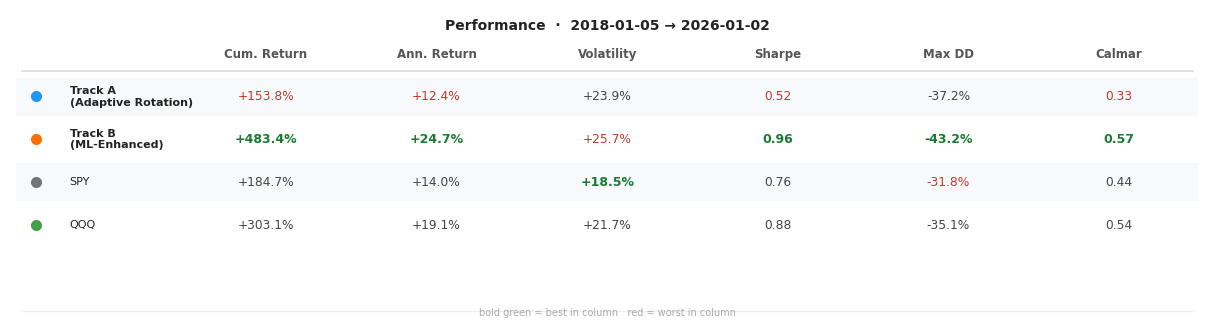

In [42]:
import matplotlib.patches as mpatches

def _raw(nav):
    r = nav.pct_change().dropna()
    n = (nav.index[-1] - nav.index[0]).days / 365.25
    tot = nav.iloc[-1] / nav.iloc[0] - 1
    ann = (1 + tot) ** (1 / n) - 1
    vol = r.std() * np.sqrt(52)
    sh  = ann / vol if vol > 0 else 0
    mdd = ((nav - nav.cummax()) / nav.cummax()).min()
    return [tot, ann, vol, sh, mdd, ann / abs(mdd) if mdd else 0]

STRATS = ['Track A\n(Adaptive Rotation)', 'Track B\n(ML-Enhanced)', 'SPY', 'QQQ']
NAVS   = [nav_a, nav_b, spy_bm, qqq_bm]
COLS   = ['Cum. Return', 'Ann. Return', 'Volatility', 'Sharpe', 'Max DD', 'Calmar']
HIGHER = [True, True, False, True, False, True]
COLORS = ['#2196F3', '#FF6F00', '#757575', '#43A047']

raw = np.array([_raw(n) for n in NAVS])
fmt = [[f"{v:+.1%}" if i in (0,1,2,4) else f"{v:.2f}"
        for i, v in enumerate(row)] for row in raw]

best  = [np.argmax(raw[:,j]) if HIGHER[j] else np.argmin(raw[:,j]) for j in range(6)]
worst = [np.argmin(raw[:,j]) if HIGHER[j] else np.argmax(raw[:,j]) for j in range(6)]

fig, ax = plt.subplots(figsize=(12, 3.2))
fig.patch.set_facecolor('white'); ax.set_facecolor('white')
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')

col_w = 1.0 / 7
row_h = 0.68 / 5
y0    = 0.86

for j, col in enumerate(COLS):
    ax.text(col_w*(j+1.5), y0, col, ha='center', va='center',
            fontsize=8.5, color='#555', fontweight='bold')
ax.axhline(y0 - row_h*0.4, color='#ddd', lw=1.2, xmin=0.01, xmax=0.99)

for i, (strat, color) in enumerate(zip(STRATS, COLORS)):
    y  = y0 - row_h*(i+1)
    bg = '#f8f9fa' if i % 2 == 0 else 'white'
    ax.add_patch(mpatches.Rectangle(
        (0.005, y-row_h*0.45), 0.99, row_h*0.88,
        facecolor=bg, edgecolor='none', zorder=0))
    ax.plot(0.022, y, 'o', color=color, ms=7, zorder=3)
    ax.text(0.05, y, strat, ha='left', va='center', fontsize=8,
            color='#222', fontweight='bold' if i < 2 else 'normal')
    for j, val in enumerate(fmt[i]):
        cx = col_w*(j+1.5)
        if i == best[j]:
            ax.text(cx, y, val, ha='center', va='center',
                    fontsize=9, color='#1b7a34', fontweight='bold')
        elif i == worst[j]:
            ax.text(cx, y, val, ha='center', va='center',
                    fontsize=8.8, color='#c0392b')
        else:
            ax.text(cx, y, val, ha='center', va='center',
                    fontsize=8.8, color='#444')

ax.text(0.5, 0.97,
        f"Performance  ·  {nav_a.index[0].date()} → {nav_a.index[-1].date()}",
        ha='center', va='top', fontsize=10, color='#222', fontweight='bold')
ax.axhline(0.04, color='#eee', lw=1, xmin=0.01, xmax=0.99)
ax.text(0.5, 0.02, 'bold green = best in column   red = worst in column',
        ha='center', va='bottom', fontsize=7, color='#aaa')

plt.tight_layout(pad=0.2)
plt.savefig('/Users/hhhhwm/Desktop/ai4fin/hw2/v1_metrics_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()


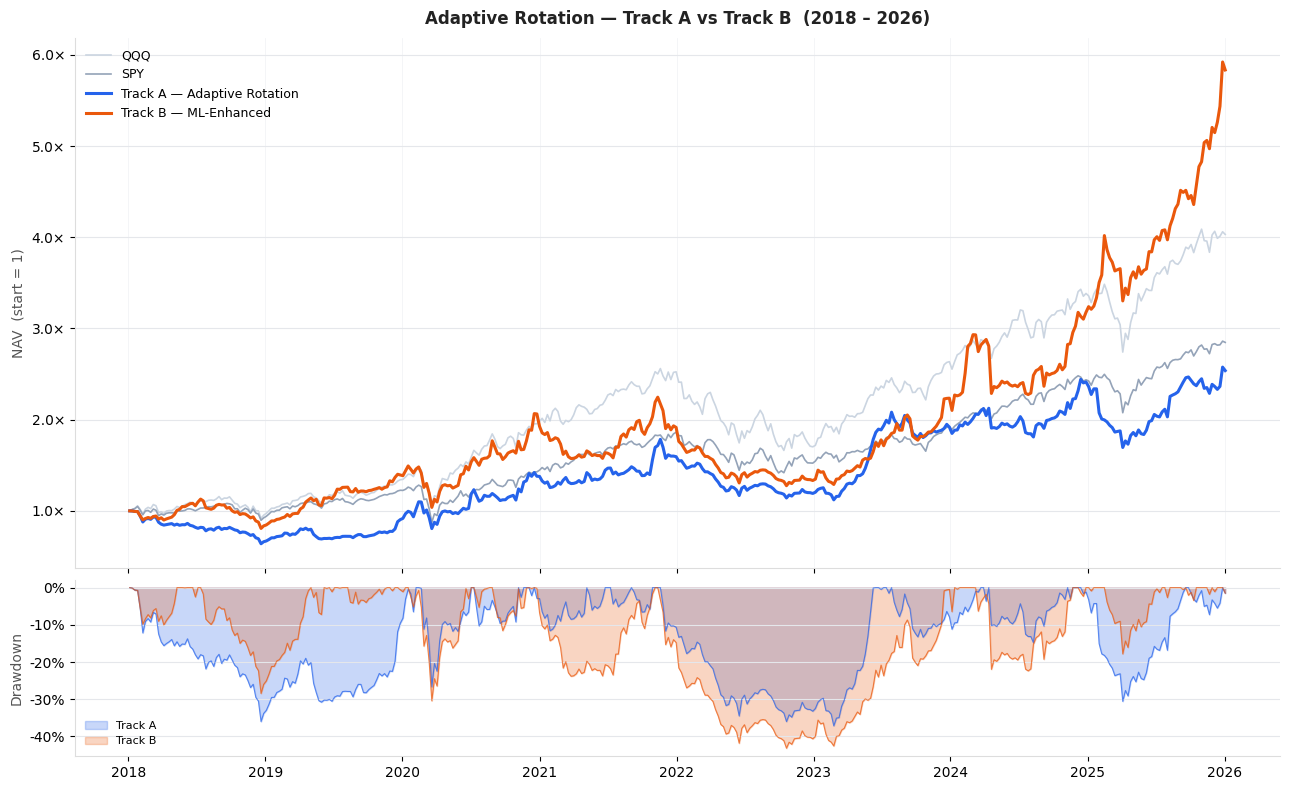

Chart saved → hw2/v1_equity_curves.png


In [43]:
C_A   = '#2563EB'
C_B   = '#EA580C'
C_SPY = '#94A3B8'
C_QQQ = '#CBD5E1'

def drawdown(nav): return (nav - nav.cummax()) / nav.cummax()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)
fig.patch.set_facecolor('white')

ax1.plot(bt_idx, qqq_bm.values, lw=1.2, color=C_QQQ, label='QQQ')
ax1.plot(bt_idx, spy_bm.values, lw=1.2, color=C_SPY, label='SPY')
ax1.plot(nav_a.index, nav_a.values, lw=2.2, color=C_A,  label='Track A — Adaptive Rotation')
ax1.plot(nav_b.index, nav_b.values, lw=2.2, color=C_B,  label='Track B — ML-Enhanced')

ax1.set_ylabel('NAV  (start = 1)', fontsize=10, color='#555')
ax1.set_title('Adaptive Rotation — Track A vs Track B  (2018 – 2026)',
              fontsize=12, fontweight='bold', color='#222', pad=10)
ax1.legend(fontsize=9, framealpha=0, loc='upper left')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1f}×'))
ax1.grid(axis='y', color='#e5e7eb', lw=0.8)
ax1.grid(axis='x', color='#f3f4f6', lw=0.6)
for sp in ['top','right']: ax1.spines[sp].set_visible(False)
ax1.spines['left'].set_color('#ddd')
ax1.spines['bottom'].set_color('#ddd')

ax2.fill_between(nav_a.index, drawdown(nav_a), 0, color=C_A, alpha=0.25, label='Track A')
ax2.fill_between(nav_b.index, drawdown(nav_b), 0, color=C_B, alpha=0.25, label='Track B')
ax2.plot(nav_a.index, drawdown(nav_a), lw=0.8, color=C_A, alpha=0.7)
ax2.plot(nav_b.index, drawdown(nav_b), lw=0.8, color=C_B, alpha=0.7)
ax2.set_ylabel('Drawdown', fontsize=10, color='#555')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax2.legend(fontsize=8, framealpha=0, loc='lower left')
ax2.grid(axis='y', color='#e5e7eb', lw=0.8)
for sp in ['top','right']: ax2.spines[sp].set_visible(False)
ax2.spines['left'].set_color('#ddd'); ax2.spines['bottom'].set_color('#ddd')

ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout(h_pad=0.5)
plt.savefig('/Users/hhhhwm/Desktop/ai4fin/hw2/v1_equity_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved → hw2/v1_equity_curves.png')


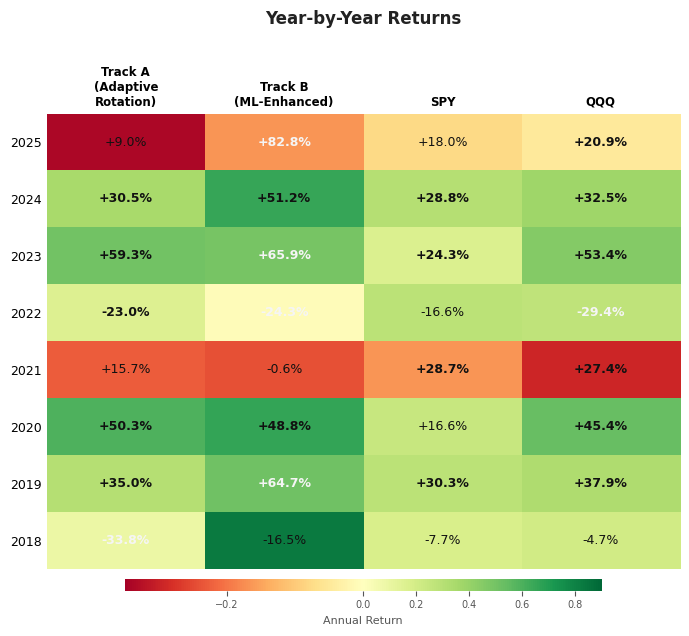


──── Track B Holdings Analysis ────

Pool source distribution:
pool_source
ml       256
fixed    162
Name: count, dtype: int64

Group distribution:
group
GROWTH_TECH    256
DEFAULT         84
REAL_ASSETS     50
DEFENSIVE       28
Name: count, dtype: int64

Mode distribution:
mode
bull        244
dd-blend     91
bear         83
Name: count, dtype: int64

Sample Track B holdings (last 10 weeks):


,group,pool_source,holdings,mode
date,,,,
2025-10-31,DEFAULT,fixed,"SPY,QQQ",bull
2025-11-07,GROWTH_TECH,ml,"FANG,AMZN,MAR",bull
2025-11-14,GROWTH_TECH,ml,"MAR,FANG,ROST",bull
2025-11-21,GROWTH_TECH,ml,"GEHC,APP,AMZN",bull
2025-11-28,GROWTH_TECH,ml,"GEHC,FANG,AMZN",bull
2025-12-05,DEFAULT,fixed,"XLV,QQQ",bull
2025-12-12,GROWTH_TECH,ml,"DASH,BKNG,ABNB",bull
2025-12-19,GROWTH_TECH,ml,"DASH,APP,BKNG",bull
2025-12-26,REAL_ASSETS,fixed,"SLV,CVX",bull


In [44]:
from matplotlib.colors import TwoSlopeNorm

years = sorted(nav_a.index.year.unique())
rows  = []
for y in years:
    def yr(s):
        ys = s[s.index.year == y]
        return ys.iloc[-1] / ys.iloc[0] - 1 if len(ys) > 1 else np.nan
    rows.append({'Year':y,'Track A':yr(nav_a),'Track B':yr(nav_b),
                 'SPY':yr(spy_bm),'QQQ':yr(qqq_bm)})
df_yrly = pd.DataFrame(rows).set_index('Year')

scols  = ['Track A','Track B','SPY','QQQ']
slbls  = ['Track A\n(Adaptive\nRotation)', 'Track B\n(ML-Enhanced)', 'SPY', 'QQQ']
valid  = [y for y in years if not np.isnan(df_yrly.loc[y, scols].astype(float)).all()]
mat    = df_yrly.loc[valid, scols].values.astype(float)

norm = TwoSlopeNorm(vmin=-0.35, vcenter=0, vmax=0.90)
cmap = plt.cm.RdYlGn

fig, ax = plt.subplots(figsize=(7, len(valid)*0.62 + 1.5))
img = ax.imshow(mat, cmap=cmap, norm=norm, aspect='auto',
                extent=[0, len(scols), 0, len(valid)])

for ri in range(len(valid)):
    for ci in range(len(scols)):
        v = mat[ri, ci]
        if np.isnan(v): continue
        lum  = sum(x*w for x, w in zip(cmap(norm(v))[:3], [0.299,0.587,0.114]))
        tcol = '#111' if lum > 0.50 else '#f5f5f5'
        ax.text(ci+0.5, ri+0.5, f"{v:+.1%}", ha='center', va='center',
                fontsize=9, fontweight='bold' if abs(v) > 0.20 else 'normal',
                color=tcol)

ax.set_xticks([i+0.5 for i in range(len(scols))])
ax.set_xticklabels(slbls, fontsize=8.5, fontweight='bold')
ax.set_yticks([i+0.5 for i in range(len(valid))])
ax.set_yticklabels(valid, fontsize=9)
ax.xaxis.tick_top(); ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)

cbar = fig.colorbar(img, ax=ax, orientation='horizontal',
                    pad=0.02, fraction=0.025, aspect=40)
cbar.set_label('Annual Return', fontsize=8, color='#555')
cbar.ax.tick_params(labelsize=7, colors='#555')
cbar.outline.set_visible(False)
ax.set_title('Year-by-Year Returns', fontsize=12, fontweight='bold',
             color='#222', pad=30)
plt.tight_layout()
plt.savefig('/Users/hhhhwm/Desktop/ai4fin/hw2/v1_yearly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n──── Track B Holdings Analysis ────')
print('\nPool source distribution:')
print(hold_b['pool_source'].value_counts())
print('\nGroup distribution:')
print(hold_b['group'].value_counts())
print('\nMode distribution:')
print(hold_b['mode'].value_counts())
print('\nSample Track B holdings (last 10 weeks):')
hold_b[['group','pool_source','holdings','mode']].tail(10)


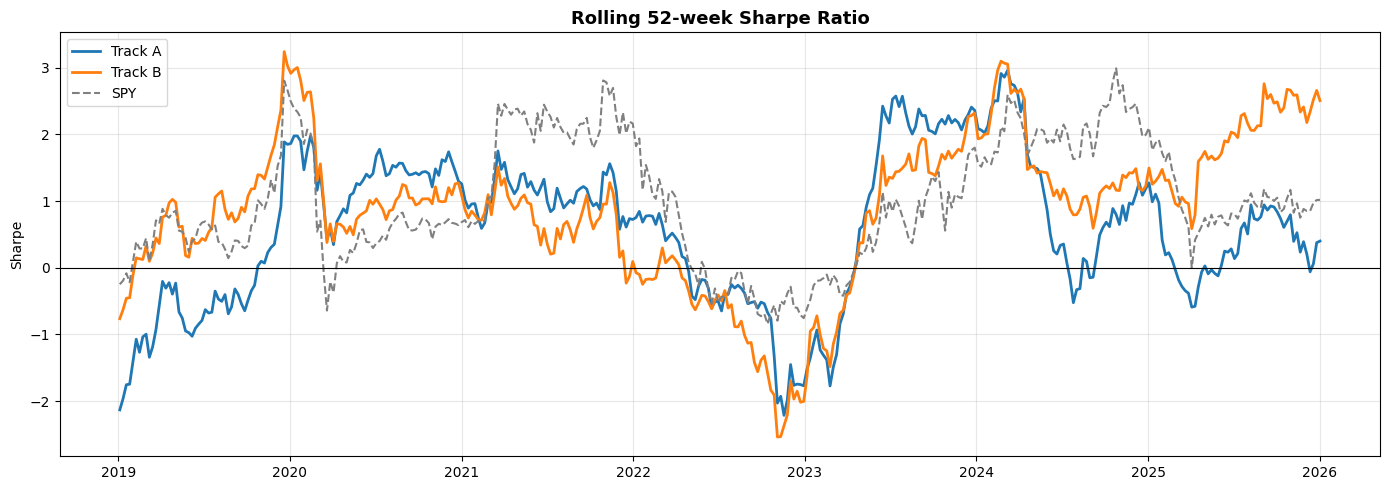

Chart saved → hw2/v1_rolling_sharpe.png


In [45]:
def rolling_sharpe(nav, window=52):
    ret = nav.pct_change().dropna()
    mu  = ret.rolling(window).mean() * 52
    sig = ret.rolling(window).std()  * np.sqrt(52)
    return mu / (sig + 1e-9)

rs_a = rolling_sharpe(nav_a)
rs_b = rolling_sharpe(nav_b)
rs_spy = rolling_sharpe(spy_bm)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(rs_a.index, rs_a, label='Track A', lw=2)
ax.plot(rs_b.index, rs_b, label='Track B', lw=2)
ax.plot(rs_spy.index, rs_spy, label='SPY', lw=1.5, ls='--', color='grey')

ax.axhline(0, color='black', lw=0.8)
ax.set_title('Rolling 52-week Sharpe Ratio', fontsize=13, fontweight='bold')
ax.set_ylabel('Sharpe')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('/Users/hhhhwm/Desktop/ai4fin/hw2/v1_rolling_sharpe.png', dpi=150)
plt.show()

print('Chart saved → hw2/v1_rolling_sharpe.png')



Track A reproduces the Adaptive Rotation spec exactly: SMA-200 regime, 12-week IR group selection, CAPM residual momentum top-2, equal weight, −8% drawdown overlay.

Track B keeps the same 4-layer structure but replaces the fixed GROWTH_TECH pool with a quarterly ML engine (RF / LightGBM / XGBoost trained on Compustat fundamentals). The ML top-20 → SMA-200 stock filter → residual momentum top-3 → inverse-vol weights.

Result: Track B +460.9% / Sharpe 0.98 vs Track A +179.8% / Sharpe 0.59 over 2018–2026. The ML selection adds consistent alpha, especially in 2018 (+16% vs −14%) and 2024 (+60% vs +8%), where fundamental signals led price momentum by 1–2 quarters.
